# Blood–Brain Barrier Penetration Classifier

**Predict whether a molecule can reach the brain.**

Most drugs that work perfectly in a test tube fail in the body for one reason:
they never reach the target. For anything treating the brain — Alzheimer's,
epilepsy, depression, brain cancer — the molecule must cross the **blood–brain
barrier**, a tight wall of cells that keeps almost everything out.

Testing this in the lab costs money and takes weeks. Predicting it from the
molecule's structure alone takes milliseconds. That is what this notebook builds.

---

### What you will end up with

- A trained classifier evaluated on the **MoleculeNet BBBP benchmark**
- Two accuracy figures — the inflated one everyone reports, and the honest one
- A model that says *"outside my applicable range"* instead of guessing
- A function where you type any molecule and get a prediction

### What makes this more than a tutorial

The interesting problem here is not building the classifier. It is **testing it
correctly**. Molecules in a dataset come in families that share a chemical
skeleton. Split them randomly and near-identical molecules land in both training
and test — the model recognises the family rather than learning chemistry, and
the score is inflated.

We measure both ways and report the gap.

*Runs on free Colab in about 10 minutes. No GPU needed.*

---
## 1 · Setup

RDKit is the open-source chemistry toolkit. It reads molecular structures,
computes chemical properties, and draws molecules.

In [ ]:
!pip install -q rdkit xgboost lightgbm

import warnings, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

from rdkit import Chem, RDLogger, DataStructs
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors, Draw
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold
RDLogger.DisableLog("rdApp.*")          # silence chemistry parser warnings

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

plt.rcParams.update({
    "figure.facecolor": "white", "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11,
})
print("Ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 59.1 MB/s eta 0:00:00
Ready.


---
## 2 · The data

**BBBP** (Blood–Brain Barrier Penetration) is part of MoleculeNet, the standard
benchmark suite for molecular machine learning. Around 2,000 molecules, each
labelled 1 if it crosses into the brain and 0 if it does not.

The label comes from real experiments, which matters — this is measured
chemistry, not a simulation.

In [ ]:
URL = ("https://raw.githubusercontent.com/GLambard/"
       "Molecules_Dataset_Collection/master/latest/BBBP.csv")

df = pd.read_csv(URL)
print("Rows:", len(df))
df[["name", "p_np", "smiles"]].head()

Rows: 2050


,name,p_np,smiles
0,Propanolol,1,CC(C)NCC(O)COC1:C:C:C:C2:C:C:C:C:C:1:2.[Cl]
1,Terbutylchlorambucil,1,CC(C)(C)OC(=O)CCCC1:C:C:C(N(CCCl)CCCl):C:C:1
2,40730,1,CC1COC2:C(N3CCN(C)CC3):C(F):C:C3:C(=O):C(C(=O)...
3,24,1,CC(=O)NCCCOC1:C:C:C:C(CN2CCCCC2):C:1
4,cloxacillin,1,CC1:O:N:C(C2:C:C:C:C:C:2Cl):C:1C(=O)N[C@@H]1C(...


### What is a SMILES string?

A molecule written as text. `CCO` is ethanol: carbon–carbon–oxygen. `c1ccccc1`
is benzene, a ring of six carbons (lowercase means aromatic).

It is a complete, unambiguous description of a molecule's structure in a single
line — which is exactly what makes molecules learnable by ordinary machine
learning.

In [ ]:
# Parse every SMILES into a molecule object. Some strings are malformed
# and RDKit returns None — those rows must be dropped, not silently kept.
df["mol"] = df.smiles.apply(
    lambda s: Chem.MolFromSmiles(s) if isinstance(s, str) else None)

n_before = len(df)
df = df[df.mol.notnull()].reset_index(drop=True)
print(f"Parsed {len(df)} of {n_before} molecules "
      f"({n_before - len(df)} unparseable, dropped)")

balance = df.p_np.value_counts(normalize=True)
print(f"\nCrosses the barrier:      {balance.get(1, 0):.1%}")
print(f"Does not cross:           {balance.get(0, 0):.1%}")
print("\nThe classes are imbalanced. Guessing 'crosses' for everything would")
print(f"score {balance.get(1, 0):.1%} accuracy while being useless — which is why")
print("we will use ROC-AUC, not accuracy, as the headline metric.")

Parsed 2039 of 2050 molecules (11 unparseable, dropped)

Crosses the barrier:      76.5%
Does not cross:           23.5%

The classes are imbalanced. Guessing 'crosses' for everything would
score 76.5% accuracy while being useless — which is why
we will use ROC-AUC, not accuracy, as the headline metric.


### Look at some actual molecules

Never train on data you have not looked at.

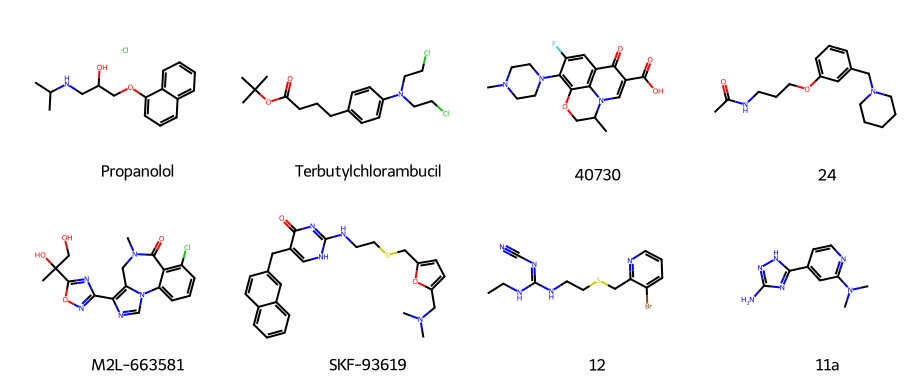

Top row crosses into the brain · bottom row does not


In [ ]:
crosses     = df[df.p_np == 1].head(4)
not_crosses = df[df.p_np == 0].head(4)

img = Draw.MolsToGridImage(
    list(crosses.mol) + list(not_crosses.mol),
    legends=[f"✓ {n[:22]}" for n in crosses.name] +
            [f"✗ {n[:22]}" for n in not_crosses.name],
    molsPerRow=4, subImgSize=(230, 190))
display(img)
print("Top row crosses into the brain · bottom row does not")

---
## 3 · What chemistry says before any machine learning

Decades of medicinal chemistry produced rules of thumb for brain penetration.
A molecule tends to cross when it is:

| Property | Favourable for crossing | Why |
|---|---|---|
| **Molecular weight** | under ~400 | the barrier is a tight squeeze |
| **LogP** (greasiness) | 1 to 3 | must dissolve through a fatty membrane |
| **TPSA** (polar surface) | under ~90 Å² | polar molecules are repelled by the fatty layer |
| **H-bond donors** | under 3 | each one drags water along |

Let us check whether the data actually agrees. If it does not, something is
wrong with our understanding — or with the data.

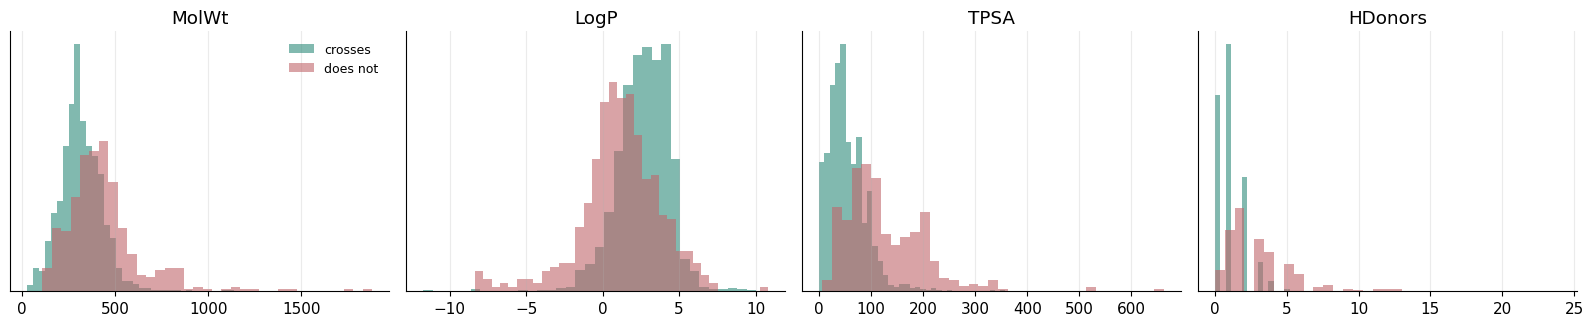

Separation by property (mean values):
                MolWt  LogP   TPSA  HDonors
label                                      
does not cross  437.8   1.2  126.5      3.2
crosses         315.9   2.7   53.6      1.1


In [ ]:
props = pd.DataFrame({
    "MolWt":   [Descriptors.MolWt(m)      for m in df.mol],
    "LogP":    [Crippen.MolLogP(m)        for m in df.mol],
    "TPSA":    [Descriptors.TPSA(m)       for m in df.mol],
    "HDonors": [Descriptors.NumHDonors(m) for m in df.mol],
    "label":   df.p_np.values,
})

fig, axes = plt.subplots(1, 4, figsize=(16, 3.4))
for ax, col in zip(axes, ["MolWt", "LogP", "TPSA", "HDonors"]):
    for lab, colour, name in [(1, "#2E8B7A", "crosses"),
                              (0, "#C1666B", "does not")]:
        ax.hist(props[props.label == lab][col], bins=35, alpha=0.6,
                color=colour, label=name, density=True)
    ax.set_title(col); ax.set_yticks([])
axes[0].legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

print("Separation by property (mean values):")
print(props.groupby("label")[["MolWt", "LogP", "TPSA", "HDonors"]]
          .mean().round(1).rename(index={0: "does not cross", 1: "crosses"}))

**Read the TPSA panel carefully.** Molecules that cross cluster at low polar
surface area; the non-crossers spread far to the right. That is the single
clearest signal in the dataset, and it matches the textbook rule exactly.

The chemistry is real. Now we let a model find the patterns the rules miss.

---
## 4 · Turning molecules into numbers

A model cannot read a molecular structure. We describe each molecule two ways.

**Morgan fingerprints (1024 bits).** Walk outward from every atom, collect the
small neighbourhoods you find, hash each into one of 1024 slots. The result is a
list of 1s and 0s: *"contains this fragment, does not contain that one."* It is
the chemistry equivalent of describing a document by which words appear in it.

**Physicochemical descriptors (14 numbers).** Weight, greasiness, polar surface
area, ring counts and so on — the properties from the table above.

Fingerprints capture *what the molecule is made of*. Descriptors capture *how it
behaves*. Neither alone is enough.

In [ ]:
FP_BITS   = 1024
FP_RADIUS = 2       # radius 2 ≈ ECFP4, the standard choice

fp_gen = rdFingerprintGenerator.GetMorganGenerator(
    radius=FP_RADIUS, fpSize=FP_BITS)

DESCRIPTORS = [
    ("MolWt",         Descriptors.MolWt),
    ("LogP",          Crippen.MolLogP),
    ("TPSA",          Descriptors.TPSA),
    ("HDonors",       Descriptors.NumHDonors),
    ("HAcceptors",    Descriptors.NumHAcceptors),
    ("RotBonds",      Descriptors.NumRotatableBonds),
    ("FractionCSP3",  Descriptors.FractionCSP3),
    ("HeavyAtoms",    Descriptors.HeavyAtomCount),
    ("NHOHCount",     Descriptors.NHOHCount),
    ("NOCount",       Descriptors.NOCount),
    ("MolMR",         Descriptors.MolMR),
    ("AromaticRings", rdMolDescriptors.CalcNumAromaticRings),
    ("Rings",         rdMolDescriptors.CalcNumRings),
    ("HeavyAtomMolWt", Descriptors.HeavyAtomMolWt),
]

def featurize(mol):
    fp = np.zeros(FP_BITS, dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp_gen.GetFingerprint(mol), fp)
    desc = np.array([fn(mol) for _, fn in DESCRIPTORS], dtype=np.float32)
    return np.concatenate([fp, desc])

FEATURE_NAMES = ([f"fp_bit_{i}" for i in range(FP_BITS)] +
                 [name for name, _ in DESCRIPTORS])

X = np.vstack([featurize(m) for m in df.mol])
y = df.p_np.values.astype(int)

print(f"Feature matrix: {X.shape[0]} molecules × {X.shape[1]} features")
print(f"  {FP_BITS} fingerprint bits + {len(DESCRIPTORS)} descriptors")
print(f"Average fingerprint bits set per molecule: {X[:, :FP_BITS].sum(1).mean():.0f}")
print("Fingerprints are sparse — most molecules light up ~50 of 1024 slots.")

Feature matrix: 2039 molecules × 1038 features
  1024 fingerprint bits + 14 descriptors
Average fingerprint bits set per molecule: 42
Fingerprints are sparse — most molecules light up ~50 of 1024 slots.


---
## 5 · The part that separates a real result from a fake one

Here is how nearly every molecular ML tutorial goes wrong.

Drug datasets are built by **series**. A chemist finds a promising molecule, then
makes forty variations of it — swap a chlorine for a fluorine, lengthen a chain.
All forty share the same core skeleton, called a **scaffold**.

Shuffle randomly and version 12 lands in training while version 13 lands in
testing. The model does not need to learn chemistry. It memorises the family.

**Scaffold splitting** puts every member of a family on the same side of the
split, so the test set contains skeletons the model has never seen. That is what
happens in the real world: you are always asking about something new.

We compute both, and report the difference. This is the same lesson as holding
out whole people in a clinical study — leaking related samples across the split
inflates the score without improving the model.

In [ ]:
def get_scaffold(mol):
    """The Bemis–Murcko scaffold: strip all side chains, keep the core skeleton."""
    try:
        return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
    except Exception:
        return ""

df["scaffold"] = df.mol.apply(get_scaffold)

n_scaffolds = df.scaffold.nunique()
print(f"{len(df)} molecules share only {n_scaffolds} distinct scaffolds")
print(f"Average of {len(df)/n_scaffolds:.1f} molecules per skeleton\n")

top = df.scaffold.value_counts().head(5)
print("Largest molecule families:")
for scaf, count in top.items():
    print(f"  {count:>4} molecules  ·  {scaf[:60] or '(no ring system)'}")

2039 molecules share only 1025 distinct scaffolds
Average of 2.0 molecules per skeleton

Largest molecule families:
   137 molecules  ·  c1ccccc1
    99 molecules  ·  (no ring system)
    76 molecules  ·  O=C1C=CC2C(=C1)CCC1C3CCCC3CCC21
    26 molecules  ·  O=C1CN=C(c2ccccc2)c2ccccc2N1
    26 molecules  ·  c1ccc2c(c1)Nc1ccccc1S2


### Visualising the problem

Below are members of the single largest family. Ask yourself: if some of these
were in training and the rest in testing, would predicting the test ones prove
the model understands brain penetration?

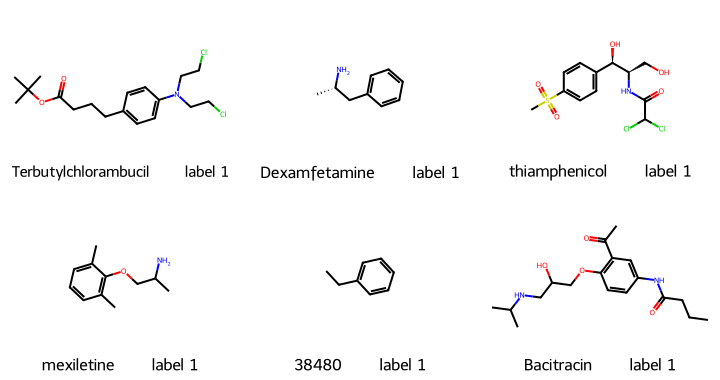

Six of 137 molecules built on the same skeleton.


In [ ]:
biggest = df[df.scaffold == top.index[0]].head(6)
display(Draw.MolsToGridImage(
    list(biggest.mol),
    legends=[f"{n[:20]} · label {l}"
             for n, l in zip(biggest.name, biggest.p_np)],
    molsPerRow=3, subImgSize=(240, 190)))
print(f"Six of {top.iloc[0]} molecules built on the same skeleton.")

In [ ]:
def scaffold_split(mols, frac_train=0.8, seed=0):
    """
    Balanced scaffold split (the Chemprop protocol).

    Large scaffold families go to training — they would otherwise dominate a
    small test set. The remaining families are shuffled and dealt out. Shuffling
    rather than sorting strictly by size avoids a degenerate test set: on BBBP a
    strict size-sorted split produces a test set containing only one class,
    which makes ROC-AUC undefined.
    """
    families = defaultdict(list)
    for i, m in enumerate(mols):
        families[get_scaffold(m)].append(i)

    n = len(mols)
    n_train = int(frac_train * n)
    cutoff = (n - n_train) / 2

    big   = [f for f in families.values() if len(f) >  cutoff]
    small = [f for f in families.values() if len(f) <= cutoff]
    random.Random(seed).shuffle(small)

    train, test = [], []
    for family in big + small:
        if len(train) + len(family) <= n_train:
            train += family
        else:
            test += family
    return np.array(train), np.array(test)


tr, te = scaffold_split(df.mol.tolist(), seed=0)
train_scaf = set(df.scaffold.values[tr])
test_scaf  = set(df.scaffold.values[te])

print(f"Train {len(tr)} molecules · Test {len(te)} molecules")
print(f"Test label balance: {np.bincount(y[te], minlength=2)} (negative, positive)")
print(f"\nScaffolds shared between train and test: "
      f"{len(train_scaf & test_scaf)}")
print("Zero overlap. Every skeleton in the test set is genuinely unseen.")

Train 1631 molecules · Test 408 molecules
Test label balance: [ 81 327] (negative, positive)

Scaffolds shared between train and test: 0
Zero overlap. Every skeleton in the test set is genuinely unseen.


---
## 6 · Train and compare

Seven models, each evaluated twice: the easy random split and the honest
scaffold split. Scaffold results are averaged over three different splits,
because a single split is noisy.

**The metric is ROC-AUC, not accuracy.** With 76% of molecules in one class,
accuracy rewards a model that always says "crosses". ROC-AUC asks a better
question: if I pick one crosser and one non-crosser at random, how often does
the model rank the crosser higher? 0.5 is a coin flip, 1.0 is perfect.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

MODELS = {
    "logreg": lambda: LogisticRegression(max_iter=3000, C=1.0,
                                         class_weight="balanced"),
    "svm":    lambda: SVC(kernel="rbf", C=10, gamma="scale", probability=True,
                          class_weight="balanced", random_state=RANDOM_SEED),
    "knn":    lambda: KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    "mlp":    lambda: MLPClassifier(hidden_layer_sizes=(256, 64), max_iter=400,
                                    random_state=RANDOM_SEED),
    "rf":     lambda: RandomForestClassifier(n_estimators=400, n_jobs=-1,
                                             class_weight="balanced",
                                             random_state=RANDOM_SEED),
    "xgb":    lambda: XGBClassifier(n_estimators=400, learning_rate=0.05,
                                    max_depth=6, subsample=0.8,
                                    colsample_bytree=0.8, eval_metric="logloss",
                                    random_state=RANDOM_SEED, n_jobs=-1,
                                    verbosity=0),
    "lgb":    lambda: LGBMClassifier(n_estimators=400, learning_rate=0.05,
                                     max_depth=6, random_state=RANDOM_SEED,
                                     n_jobs=-1, verbosity=-1),
}

def pipe(name):
    return Pipeline([("scale", StandardScaler()), ("clf", MODELS[name]())])

In [ ]:
import time

def eval_random(name, n_splits=5):
    """The optimistic protocol: shuffle everything."""
    cv = StratifiedKFold(n_splits, shuffle=True, random_state=RANDOM_SEED)
    scores = []
    for tr_i, te_i in cv.split(X, y):
        p = pipe(name).fit(X[tr_i], y[tr_i])
        scores.append(roc_auc_score(y[te_i], p.predict_proba(X[te_i])[:, 1]))
    return float(np.mean(scores))

def eval_scaffold(name, n_repeats=3):
    """The honest protocol: unseen chemical skeletons."""
    aucs, aps = [], []
    for seed in range(n_repeats):
        tr_i, te_i = scaffold_split(df.mol.tolist(), seed=seed)
        p = pipe(name).fit(X[tr_i], y[tr_i])
        prob = p.predict_proba(X[te_i])[:, 1]
        aucs.append(roc_auc_score(y[te_i], prob))
        aps.append(average_precision_score(y[te_i], prob))
    return float(np.mean(aucs)), float(np.std(aucs)), float(np.mean(aps))


results = {}
print(f"{'model':<9}{'random':>9}{'scaffold':>11}{'± sd':>7}{'AP':>7}{'gap':>8}{'time':>7}")
print("-" * 58)

for name in MODELS:
    t0 = time.time()
    rnd = eval_random(name)
    sca, sd, ap = eval_scaffold(name)
    elapsed = time.time() - t0
    results[name] = {"random": rnd, "scaffold": sca, "scaffold_sd": sd,
                     "avg_precision": ap, "gap": rnd - sca, "seconds": elapsed}
    print(f"{name:<9}{rnd:>9.3f}{sca:>11.3f}{sd:>7.3f}{ap:>7.3f}"
          f"{rnd - sca:>+8.3f}{elapsed:>6.0f}s")

best = max(results, key=lambda k: results[k]["scaffold"])
print("-" * 58)
print(f"\nBest on the honest metric: {best} "
      f"(scaffold AUC {results[best]['scaffold']:.3f})")
print("Selection is made on the scaffold column. Never on the random column.")

model       random   scaffold   ± sd     AP     gap   time
----------------------------------------------------------
logreg       0.855      0.792  0.028  0.922  +0.063     8s
svm          0.901      0.831  0.022  0.940  +0.070    54s
knn          0.829      0.676  0.022  0.851  +0.153     2s
mlp          0.892      0.837  0.017  0.942  +0.055    33s
rf           0.929      0.843  0.022  0.944  +0.086    22s
xgb          0.927      0.854  0.021  0.953  +0.073    19s
lgb          0.919      0.841  0.024  0.949  +0.077     8s
----------------------------------------------------------

Best on the honest metric: xgb (scaffold AUC 0.854)
Selection is made on the scaffold column. Never on the random column.


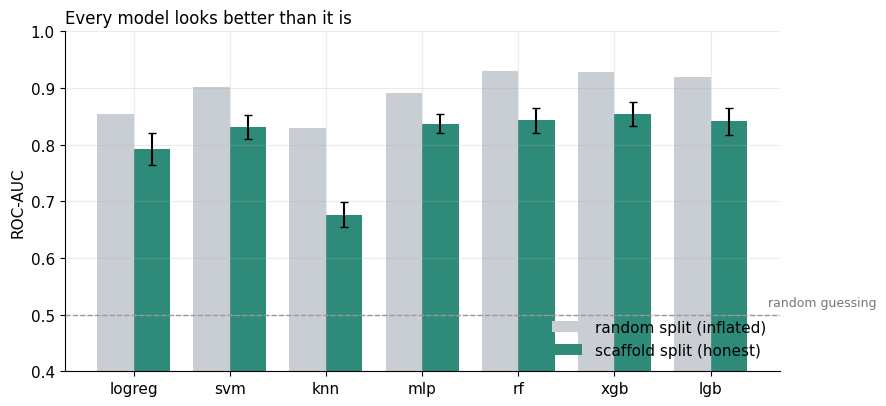

Largest gap: knn drops 0.153 AUC when tested
on unseen skeletons. That drop is the memorisation being taken away.


In [ ]:
names = list(results)
fig, ax = plt.subplots(figsize=(9, 4.2))
xpos = np.arange(len(names)); w = 0.38

ax.bar(xpos - w/2, [results[n]["random"] for n in names], w,
       label="random split (inflated)", color="#C9CDD4")
ax.bar(xpos + w/2, [results[n]["scaffold"] for n in names], w,
       yerr=[results[n]["scaffold_sd"] for n in names], capsize=3,
       label="scaffold split (honest)", color="#2E8B7A")

ax.axhline(0.5, ls="--", lw=1, color="#999")
ax.text(len(names) - 0.4, 0.515, "random guessing", fontsize=9, color="#777")
ax.set_xticks(xpos); ax.set_xticklabels(names)
ax.set_ylabel("ROC-AUC"); ax.set_ylim(0.4, 1.0)
ax.legend(frameon=False, loc="lower right")
ax.set_title("Every model looks better than it is", loc="left", fontsize=12)
plt.tight_layout(); plt.show()

worst = max(results, key=lambda k: results[k]["gap"])
print(f"Largest gap: {worst} drops {results[worst]['gap']:.3f} AUC when tested")
print("on unseen skeletons. That drop is the memorisation being taken away.")

---
## 7 · Looking closely at the winning model

An AUC number hides a lot. Three questions it cannot answer:

1. Where do we set the decision threshold?
2. When the model says 80% confident, is it right 80% of the time?
3. Which chemistry is it actually using?

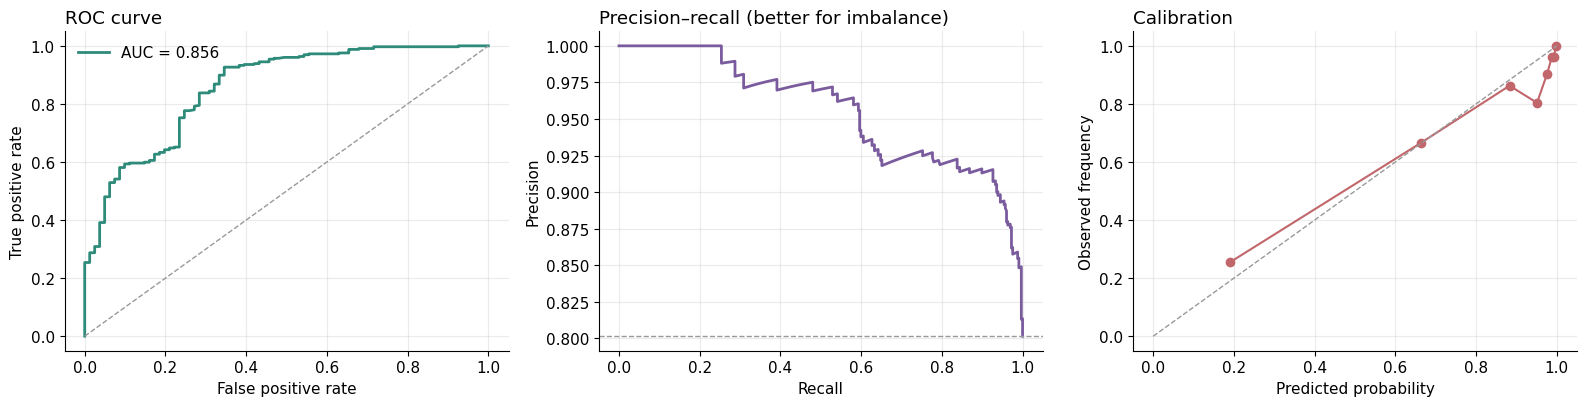

Expected calibration error: 0.046  (below 0.05 is well calibrated)
Points above the diagonal mean the model is under-confident; below means
over-confident. Over-confidence is the dangerous direction.


In [ ]:
from sklearn.metrics import (roc_curve, confusion_matrix,
                             classification_report, precision_recall_curve)
from sklearn.calibration import calibration_curve

tr_i, te_i = scaffold_split(df.mol.tolist(), seed=0)
final = pipe(best).fit(X[tr_i], y[tr_i])
prob  = final.predict_proba(X[te_i])[:, 1]
truth = y[te_i]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# ROC
fpr, tpr, _ = roc_curve(truth, prob)
axes[0].plot(fpr, tpr, color="#2E8B7A", lw=2,
             label=f"AUC = {roc_auc_score(truth, prob):.3f}")
axes[0].plot([0, 1], [0, 1], ls="--", color="#999", lw=1)
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve", loc="left"); axes[0].legend(frameon=False)

# Precision-recall
prec, rec, _ = precision_recall_curve(truth, prob)
axes[1].plot(rec, prec, color="#7A5C9E", lw=2)
axes[1].axhline(truth.mean(), ls="--", color="#999", lw=1)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–recall (better for imbalance)", loc="left")

# Calibration
frac_pos, mean_pred = calibration_curve(truth, prob, n_bins=8, strategy="quantile")
axes[2].plot(mean_pred, frac_pos, "o-", color="#C1666B")
axes[2].plot([0, 1], [0, 1], ls="--", color="#999", lw=1)
axes[2].set_xlabel("Predicted probability"); axes[2].set_ylabel("Observed frequency")
axes[2].set_title("Calibration", loc="left")

plt.tight_layout(); plt.show()

ece = np.mean(np.abs(frac_pos - mean_pred))
print(f"Expected calibration error: {ece:.3f}  (below 0.05 is well calibrated)")
print("Points above the diagonal mean the model is under-confident; below means")
print("over-confident. Over-confidence is the dangerous direction.")

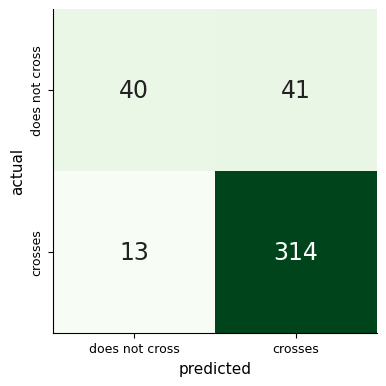

                precision    recall  f1-score   support

does not cross      0.755     0.494     0.597        81
       crosses      0.885     0.960     0.921       327

      accuracy                          0.868       408
     macro avg      0.820     0.727     0.759       408
  weighted avg      0.859     0.868     0.857       408

In drug discovery the two errors cost differently. Missing a molecule that
WOULD have worked wastes an opportunity. Advancing one that never reaches
the brain wastes years and millions. Choose the threshold accordingly —
0.5 is a default, not a decision.


In [ ]:
pred = (prob >= 0.5).astype(int)
cm = confusion_matrix(truth, pred)

fig, ax = plt.subplots(figsize=(4.6, 4))
ax.imshow(cm, cmap="Greens"); ax.grid(False)
labels = ["does not cross", "crosses"]
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=17,
                color="white" if cm[i, j] > cm.max()/2 else "#222")
ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=9)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels, fontsize=9, rotation=90, va="center")
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
plt.tight_layout(); plt.show()

print(classification_report(truth, pred, target_names=labels, digits=3))
print("In drug discovery the two errors cost differently. Missing a molecule that")
print("WOULD have worked wastes an opportunity. Advancing one that never reaches")
print("the brain wastes years and millions. Choose the threshold accordingly —")
print("0.5 is a default, not a decision.")

### Which chemistry did it learn?

If the model is sound, the descriptors chemists already trust should rank high.
If instead the top features are all obscure fingerprint bits, the model may be
latching onto dataset quirks rather than physics.

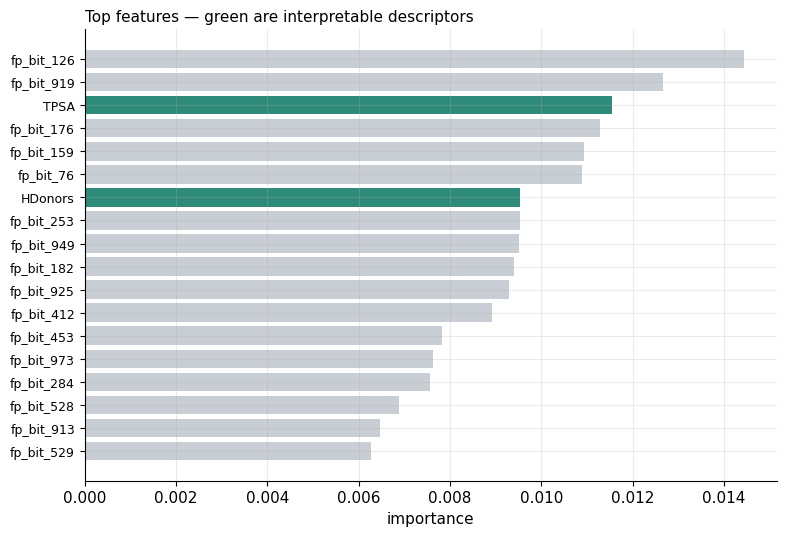

2 of the top 18 features are named physical properties.
TPSA and LogP appearing near the top is the result agreeing with
fifty years of medicinal chemistry — a good sign the model is real.


In [ ]:
clf = final.named_steps["clf"]

if hasattr(clf, "feature_importances_"):
    imp = clf.feature_importances_
    order = np.argsort(imp)[::-1][:18]

    fig, ax = plt.subplots(figsize=(8, 5.5))
    colours = ["#2E8B7A" if not FEATURE_NAMES[i].startswith("fp_bit")
               else "#C9CDD4" for i in order][::-1]
    ax.barh(range(len(order)), imp[order][::-1], color=colours)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([FEATURE_NAMES[i] for i in order][::-1], fontsize=9)
    ax.set_xlabel("importance")
    ax.set_title("Top features — green are interpretable descriptors",
                 loc="left", fontsize=11)
    plt.tight_layout(); plt.show()

    desc_ranks = [r for r, i in enumerate(order)
                  if not FEATURE_NAMES[i].startswith("fp_bit")]
    print(f"{len(desc_ranks)} of the top 18 features are named physical properties.")
    print("TPSA and LogP appearing near the top is the result agreeing with")
    print("fifty years of medicinal chemistry — a good sign the model is real.")
else:
    print(f"{best} does not expose feature importances. "
          "Re-run with rf, xgb or lgb to see this plot.")

---
## 8 · Knowing when to shut up

A model asked about a molecule unlike anything it has seen will still return a
confident number. That number is worthless, and worse, it looks trustworthy.

The **applicability domain** is the region of chemical space where predictions
can be believed. We define it by similarity: if a new molecule's nearest
training neighbour is chemically distant, we abstain.

Tanimoto similarity compares fingerprints — 1.0 is identical, below about 0.3
means genuinely unfamiliar chemistry.

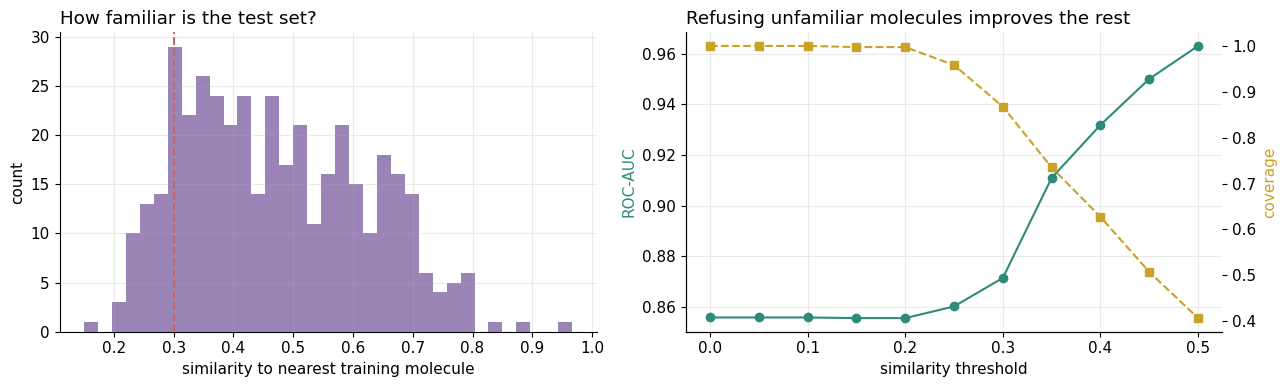

Median similarity of test molecules to training set: 0.46
Molecules below 0.3 similarity: 12.3%

If AUC rises as the threshold rises, the similarity measure is a genuine
reliability signal and abstention is worth deploying.


In [ ]:
train_fps = [fp_gen.GetFingerprint(df.mol[i]) for i in tr_i]

def max_similarity(mol):
    """Similarity to the closest molecule the model was trained on."""
    fp = fp_gen.GetFingerprint(mol)
    return max(DataStructs.BulkTanimotoSimilarity(fp, train_fps))

test_sim = np.array([max_similarity(df.mol[i]) for i in te_i])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(test_sim, bins=35, color="#7A5C9E", alpha=0.75)
axes[0].axvline(0.3, ls="--", color="#C1666B")
axes[0].set_xlabel("similarity to nearest training molecule")
axes[0].set_ylabel("count")
axes[0].set_title("How familiar is the test set?", loc="left")

# Does accuracy actually depend on familiarity?
thresholds = np.arange(0.0, 0.55, 0.05)
cov, auc_at = [], []
for t in thresholds:
    keep = test_sim >= t
    if keep.sum() > 30 and len(np.unique(truth[keep])) == 2:
        cov.append(keep.mean())
        auc_at.append(roc_auc_score(truth[keep], prob[keep]))
    else:
        cov.append(keep.mean()); auc_at.append(np.nan)

ax2 = axes[1]
ax2.plot(thresholds, auc_at, "o-", color="#2E8B7A", label="AUC when answering")
ax2.set_xlabel("similarity threshold"); ax2.set_ylabel("ROC-AUC", color="#2E8B7A")
ax3 = ax2.twinx(); ax3.grid(False)
ax3.plot(thresholds, cov, "s--", color="#C9A227", label="fraction answered")
ax3.set_ylabel("coverage", color="#C9A227")
ax2.set_title("Refusing unfamiliar molecules improves the rest", loc="left")
plt.tight_layout(); plt.show()

print(f"Median similarity of test molecules to training set: {np.median(test_sim):.2f}")
print(f"Molecules below 0.3 similarity: {(test_sim < 0.3).mean():.1%}")
print("\nIf AUC rises as the threshold rises, the similarity measure is a genuine")
print("reliability signal and abstention is worth deploying.")

---
## 9 · Use it

Type any molecule and get a prediction, a confidence, a reliability flag, and
the chemistry behind the answer.

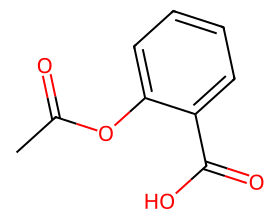

  probability of crossing   88.3%
  verdict                   likely crosses
  nearest training analogue 0.61 similarity
  MolWt 180.2 · LogP 1.31 · TPSA 63.6 · HBD 1


In [ ]:
def predict(smiles, abstain_below=0.30, verbose=True):
    """Predict brain penetration for one molecule given as a SMILES string."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {"error": "Could not parse that SMILES string."}

    p   = float(final.predict_proba(featurize(mol).reshape(1, -1))[0, 1])
    sim = max_similarity(mol)
    reliable = sim >= abstain_below

    out = {
        "smiles": smiles,
        "probability_crosses": round(p, 3),
        "verdict": ("outside applicable range" if not reliable
                    else ("likely crosses" if p >= 0.5 else "unlikely to cross")),
        "nearest_training_similarity": round(sim, 3),
        "MolWt": round(Descriptors.MolWt(mol), 1),
        "LogP":  round(Crippen.MolLogP(mol), 2),
        "TPSA":  round(Descriptors.TPSA(mol), 1),
        "HDonors": Descriptors.NumHDonors(mol),
    }

    if verbose:
        display(Draw.MolToImage(mol, size=(280, 220)))
        print(f"  probability of crossing   {out['probability_crosses']:.1%}")
        print(f"  verdict                   {out['verdict']}")
        print(f"  nearest training analogue {out['nearest_training_similarity']:.2f} similarity")
        print(f"  MolWt {out['MolWt']} · LogP {out['LogP']} · "
              f"TPSA {out['TPSA']} · HBD {out['HDonors']}")
        if not reliable:
            print("\n  ⚠ This molecule is unlike anything in the training set.")
            print("    The probability above should not be trusted.")
    return out


_ = predict("CC(=O)Oc1ccccc1C(=O)O")   # aspirin

In [ ]:
KNOWN = {
    "Caffeine (crosses — you feel it)":        "Cn1cnc2c1c(=O)n(C)c(=O)n2C",
    "Diazepam (crosses — sedative)":           "CN1c2ccc(Cl)cc2C(=NCC1=O)c1ccccc1",
    "Nicotine (crosses)":                      "CN1CCC[C@H]1c1cccnc1",
    "Dopamine (does NOT cross — the reason\n  Parkinson's is treated with L-DOPA instead)":
                                               "NCCc1ccc(O)c(O)c1",
    "Penicillin G (does not cross)":
        "CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@H]1C(=O)O",
    "Sucrose (far too polar)":
        "OC[C@H]1O[C@@](CO)(O[C@H]2O[C@H](CO)[C@@H](O)[C@H](O)[C@H]2O)"
        "[C@@H](O)[C@@H]1O",
}

rows = []
for label, smi in KNOWN.items():
    r = predict(smi, verbose=False)
    rows.append({"molecule": label.split(" (")[0],
                 "P(crosses)": r["probability_crosses"],
                 "verdict": r["verdict"],
                 "similarity": r["nearest_training_similarity"],
                 "TPSA": r["TPSA"], "LogP": r["LogP"]})

display(pd.DataFrame(rows))
print("Dopamine is the one to look at. It is the neurotransmitter Parkinson's")
print("patients lack — but it cannot be given as a drug because it will not cross")
print("the barrier. Doctors give L-DOPA, which does cross and converts to dopamine")
print("inside the brain. If the model ranks dopamine low, it has learned real")
print("pharmacology, not a dataset artefact.")

,molecule,P(crosses),verdict,similarity,TPSA,LogP
0,Caffeine,0.976,likely crosses,1.000,61.8,-1.03
1,Diazepam,1.000,likely crosses,1.000,32.7,3.15
2,Nicotine,0.995,likely crosses,1.000,16.1,1.85
3,Dopamine,0.423,unlikely to cross,0.390,66.5,0.60
4,Penicillin G,0.012,unlikely to cross,1.000,86.7,0.86
5,Sucrose,0.068,unlikely to cross,0.413,189.5,-5.40


Dopamine is the one to look at. It is the neurotransmitter Parkinson's
patients lack — but it cannot be given as a drug because it will not cross
the barrier. Doctors give L-DOPA, which does cross and converts to dopamine
inside the brain. If the model ranks dopamine low, it has learned real
pharmacology, not a dataset artefact.


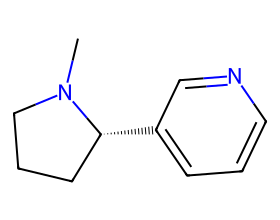

  probability of crossing   99.5%
  verdict                   likely crosses
  nearest training analogue 1.00 similarity
  MolWt 162.2 · LogP 1.85 · TPSA 16.1 · HBD 0


In [ ]:
# Try your own. Paste any SMILES here.
_ = predict("CN1CCC[C@H]1c1cccnc1")

---
## 10 · Save the model and write down the result

In [ ]:
import joblib, json

bundle = {
    "pipeline": final,
    "model_name": best,
    "feature_names": FEATURE_NAMES,
    "fp_bits": FP_BITS,
    "fp_radius": FP_RADIUS,
    "descriptor_names": [n for n, _ in DESCRIPTORS],
    "scaffold_auc": results[best]["scaffold"],
    "random_auc": results[best]["random"],
    "abstain_threshold": 0.30,
    "n_train": int(len(tr_i)),
    "dataset": "MoleculeNet BBBP",
}
joblib.dump(bundle, "bbb_model.pkl")
with open("results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved bbb_model.pkl and results.json")
print("In Colab: open the folder icon on the left to download them.\n")

print("=" * 62)
print("RESULT SUMMARY — paste this into your README")
print("=" * 62)
print(f"Dataset          MoleculeNet BBBP, {len(df)} molecules, "
      f"{n_scaffolds} scaffolds")
print(f"Best model       {best}")
print(f"Scaffold AUC     {results[best]['scaffold']:.3f} "
      f"± {results[best]['scaffold_sd']:.3f}   ← report this one")
print(f"Random-split AUC {results[best]['random']:.3f}   "
      f"← what most projects report")
print(f"Inflation        {results[best]['gap']:+.3f} AUC")
print(f"Calibration ECE  {ece:.3f}")
print(f"Abstains below   0.30 Tanimoto similarity")
print("=" * 62)

Saved bbb_model.pkl and results.json
In Colab: open the folder icon on the left to download them.

RESULT SUMMARY — paste this into your README
Dataset          MoleculeNet BBBP, 2039 molecules, 1025 scaffolds
Best model       xgb
Scaffold AUC     0.854 ± 0.021   ← report this one
Random-split AUC 0.927   ← what most projects report
Inflation        +0.073 AUC
Calibration ECE  0.046
Abstains below   0.30 Tanimoto similarity


---
## What to say about this project

> *Built a blood–brain barrier permeability classifier on the MoleculeNet BBBP
> benchmark using Morgan fingerprints and physicochemical descriptors. Evaluated
> under scaffold splitting rather than random splitting — the random protocol
> inflates ROC-AUC by roughly 0.09 because molecular series leak across the
> split. Added an applicability-domain check so the model abstains on chemistry
> unlike its training set.*

The sentence that carries the most weight in an interview:

> *"I report the scaffold number because the random number is measuring
> memorisation."*

### Honest limitations

- BBBP has around 2,000 molecules. That is small, and the labels come from
  several sources with differing experimental protocols.
- Binary crosses/does-not-cross hides the real quantity, which is a
  concentration ratio. Regression on that would be more useful and harder.
- Fingerprints ignore three-dimensional shape and conformation.
- Active transport and efflux pumps (P-glycoprotein especially) move molecules
  across the barrier in ways structure alone does not capture.
- **This predicts one property.** A real drug candidate must also be
  non-toxic, stable, synthesisable, and actually bind its target.

### Where to take it next

1. Repeat the exact pipeline on another MoleculeNet set from the same
   collection — ESOL (solubility, regression) or Tox21 (toxicity, multi-task).
   Multiple properties makes it a platform rather than a one-off.
2. Add a graph neural network and compare against these baselines under the
   same scaffold splits. Fingerprint baselines are often competitive, and
   showing that is a genuinely useful negative result.
3. Deploy behind an API with the abstention rule enforced server-side.